# Nama:SISTRA AMANDA SINAGA
# NIM:4222301011
# Kelas:PAGI A

In [1]:
!pip install numpy pandas seaborn matplotlib

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## Load Our Dataset

In [3]:
df = pd.read_csv('berat_tinggi.csv')

## EDA

Text(0.5, 1.0, 'Sebaran Nilai berat vs tinggi')

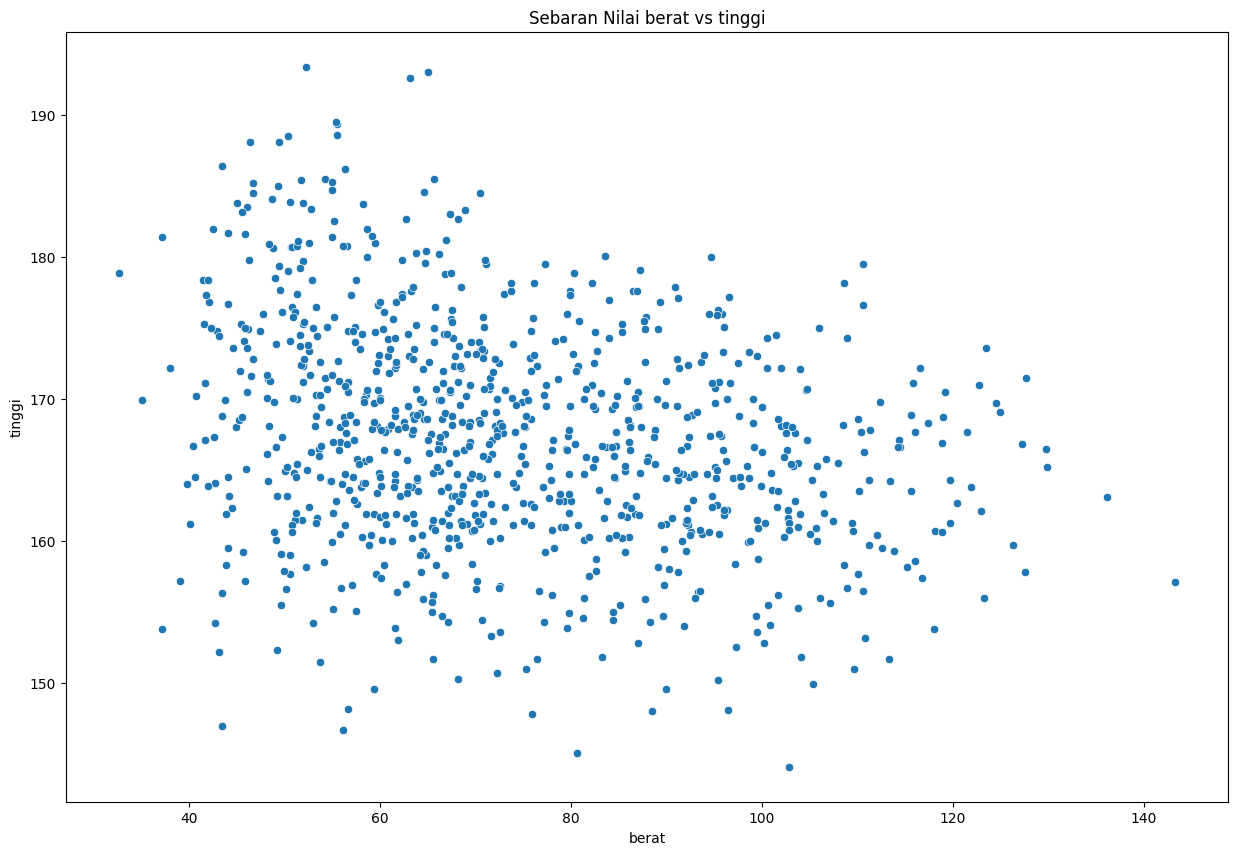

In [4]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='berat', y='tinggi')
plt.title('Sebaran Nilai berat vs tinggi')

In [5]:
df.describe()

,berat,tinggi
count,900.000000,900.000000
mean,74.087667,167.314889
std,20.645045,7.937754
min,32.600000,144.100000
25%,58.100000,161.800000
50%,70.150000,167.050000
75%,89.025000,172.500000
max,143.300000,193.400000


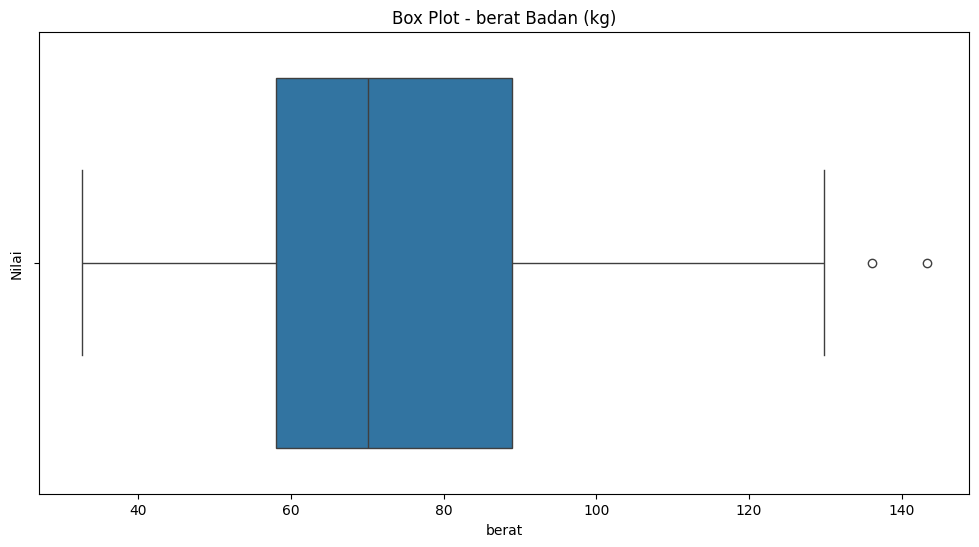

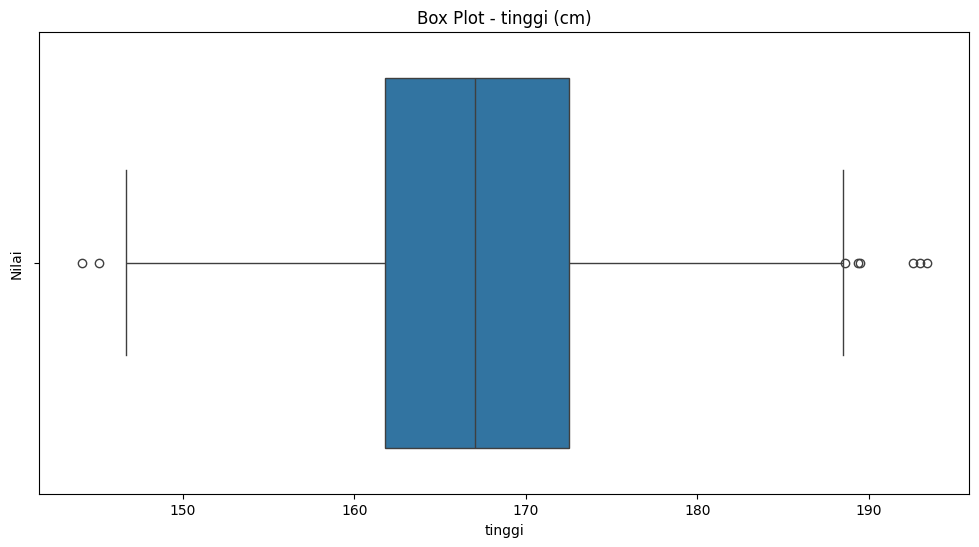

In [6]:
# Looping untuk kolom 'berat' dan 'tinggi'
columns = ['berat', 'tinggi']

for col in columns:
    # Box plot
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=col, data=df)
    plt.title(f'Box Plot - {col} Badan (kg)' if col == 'berat' else f'Box Plot - {col} (cm)')
    plt.xlabel(col)
    plt.ylabel('Nilai')
    plt.show()

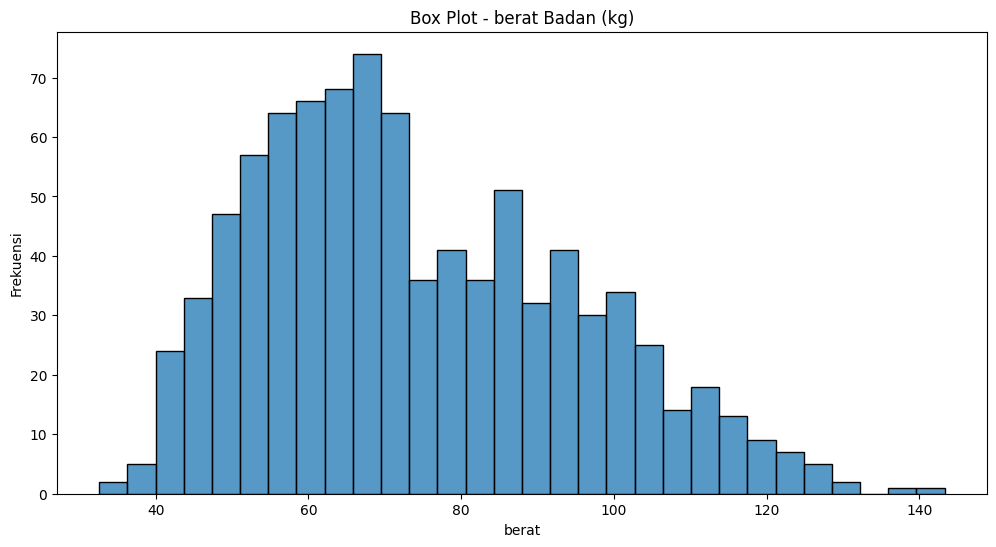

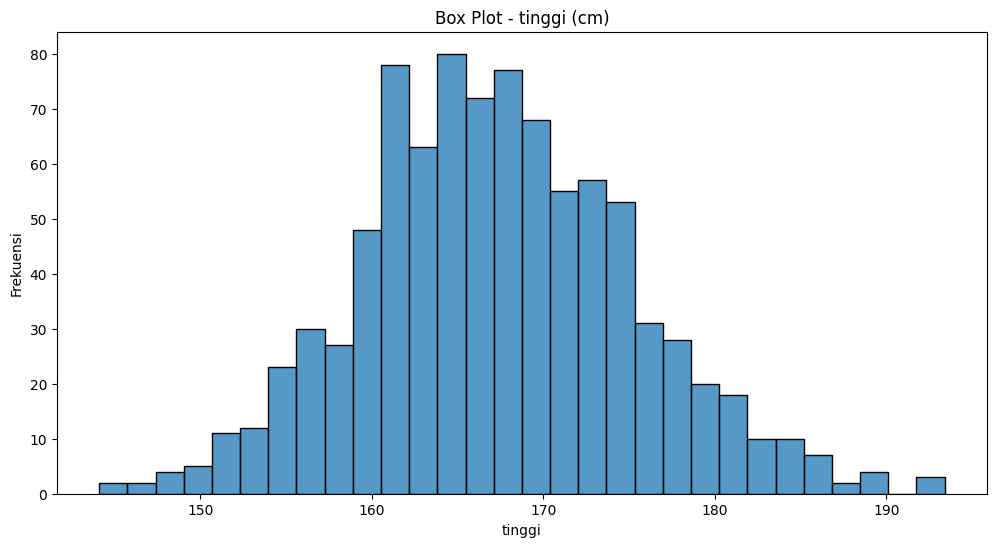

In [7]:
for col in columns:
    # Histogram
    plt.figure(figsize=(12, 6))
    sns.histplot(df[col], bins=30, kde=False)
    plt.title(f'Box Plot - {col} Badan (kg)' if col == 'berat' else f'Box Plot - {col} (cm)')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.show()

## Feature Engineering
* Unsupervised tidak perlu dilakukan splitting
1. Drop Duplikat
2. Outlier Handling (opsional)-> pada step ini tidak perlu, karena berat dan tinggi masih wajar untuk nilai seperti itu
3. Feature Scalling

In [8]:
# Drop Duplicates

print(f"Dataframe dimension before duplication drop {df.shape[0]}")

df = df.drop_duplicates().reset_index(drop=True)

print(f"Dataframe dimension after duplication drop {df.shape[0]}")

Dataframe dimension before duplication drop 900
Dataframe dimension after duplication drop 897


dari hasil running program diatas, tidak ada data yg duplikat

In [9]:
fitur_columns = ['berat', 'tinggi']
X = df[fitur_columns].values
y = df['deskripsi'].values #anotator label

In [10]:
!pip install scikit-learn

In [13]:
# Feature Scalling
from sklearn.preprocessing import StandardScaler
X_std = StandardScaler().fit_transform(X)
df_scalling = pd.DataFrame(data = X_std, columns = fitur_columns )
df_scalling.describe()

,berat,tinggi
count,8.970000e+02,8.970000e+02
mean,-2.544725e-16,-1.677340e-15
std,1.000558e+00,1.000558e+00
min,-2.008278e+00,-2.930066e+00
25%,-7.720710e-01,-6.983382e-01
50%,-1.951741e-01,-3.008079e-02
75%,7.259216e-01,6.507852e-01
max,3.358316e+00,3.285989e+00


In [14]:
X_std

array([[-0.31637096,  0.10861414],
       [ 2.18028327,  0.17165728],
       [-0.36484968, -1.59355085],
       ...,
       [ 1.33190562,  0.90295779],
       [ 0.75985669, -1.316161  ],
       [-0.5539167 ,  0.08339688]])

In [15]:
df_scalling

,berat,tinggi
0,-0.316371,0.108614
1,2.180283,0.171657
2,-0.364850,-1.593551
3,-0.990225,-0.105733
4,-0.369698,-0.483991
...,...,...
892,0.202351,-0.988337
893,0.052067,0.096006
894,1.331906,0.902958
895,0.759857,-1.316161


## TO DO!
- Lengkapi Code dibawah ini, untuk mengecek distribusi sebelum dan setelah dilakukan feature scalling menggunakan standar scaller

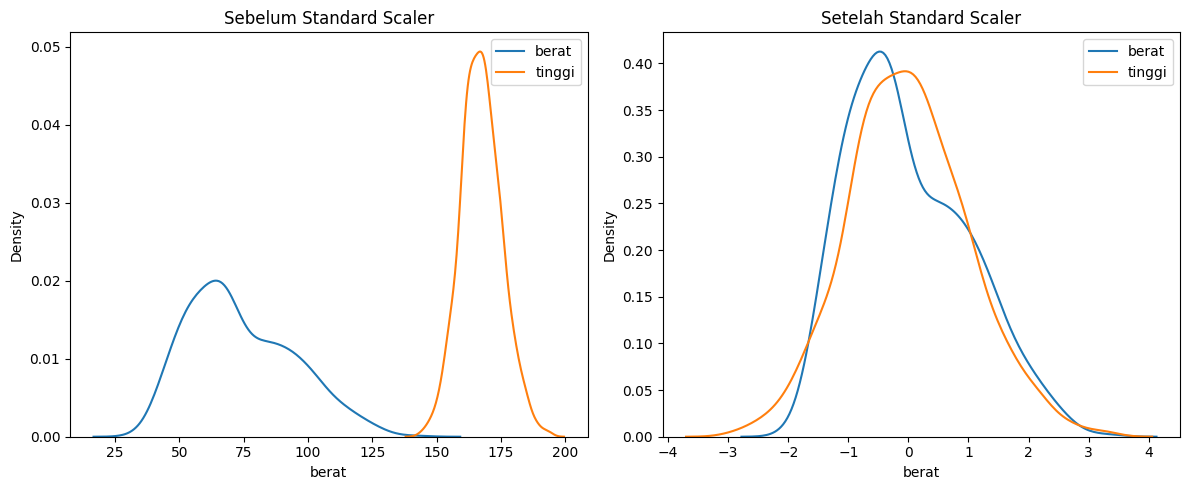

In [16]:
# Pastikan data dalam bentuk DataFrame
X = df[fitur_columns]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# Ubah ke DataFrame lagi
X_std = pd.DataFrame(X_std, columns=fitur_columns)

# Plot
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Sebelum scaling (KDE plot)
for col in X.columns:
    sns.kdeplot(X[col], ax=ax1, label=col, fill=False)

# Setelah scaling (KDE plot)
for col in X_std.columns:
    sns.kdeplot(X_std[col], ax=ax2, label=col, fill=False)

# Judul
ax1.set_title('Sebelum Standard Scaler')
ax2.set_title('Setelah Standard Scaler')

# Legend
ax1.legend()
ax2.legend()

plt.tight_layout()
plt.show()

### Tulis Interpretasi dari hasil evaluasi diatas :

### Isi disini

1. **Perbedaan Skala Sebelum Scaling**: Sebelum diterapkan Standard Scaler, fitur `berat`
   memiliki rentang nilai sekitar 25–150, sedangkan fitur `tinggi` berkisar antara 125–200.
   Perbedaan skala yang besar ini dapat menyebabkan model machine learning memberikan bobot
   berlebih pada fitur dengan nilai lebih besar, sehingga hasil prediksi menjadi bias.

2. **Distribusi Berat Bersifat Bimodal**: Grafik KDE fitur `berat` menunjukkan dua puncak
   (bimodal) di sekitar nilai 60 dan 75, mengindikasikan adanya dua kelompok berbeda dalam
   data (kemungkinan representasi kelompok dengan karakteristik berat badan yang berbeda).

3. **Distribusi Tinggi Bersifat Normal (Unimodal)**: Fitur `tinggi` memiliki distribusi
   yang lebih simetris dengan satu puncak tajam, menandakan data tinggi lebih seragam
   dan mendekati distribusi normal.

4. **Skala Seragam Setelah Scaling**: Setelah Standard Scaler diterapkan, kedua fitur
   memiliki mean ≈ 0 dan standar deviasi ≈ 1, sehingga berada pada skala yang setara.
   Rentang nilai bergeser ke kisaran -4 hingga +4 untuk kedua fitur.

5. **Bentuk Distribusi Tidak Berubah**: Standard Scaler hanya melakukan transformasi
   linear (geser dan skalakan), sehingga bentuk distribusi asli tetap dipertahankan —
   `berat` tetap bimodal dan `tinggi` tetap unimodal setelah proses scaling.

6. **Manfaat untuk Model Machine Learning**: Dengan skala yang seragam, algoritma
   berbasis jarak (KNN, SVM, K-Means) dan optimasi berbasis gradient descent akan
   bekerja lebih optimal, konvergen lebih cepat, dan menghasilkan performa model
   yang lebih baik dibandingkan menggunakan data mentah tanpa scaling.

## K-means Clustering
Pada pembahasan kali ini akan diuji 2 metode pemilihan nilai cluster (K) yang terbaik, mendekati distribusi pada label anotator.
1. Metode Elbow
2. Via-Score plot

### Metode Elbow

Text(0, 0.5, 'Intertia / WSS')

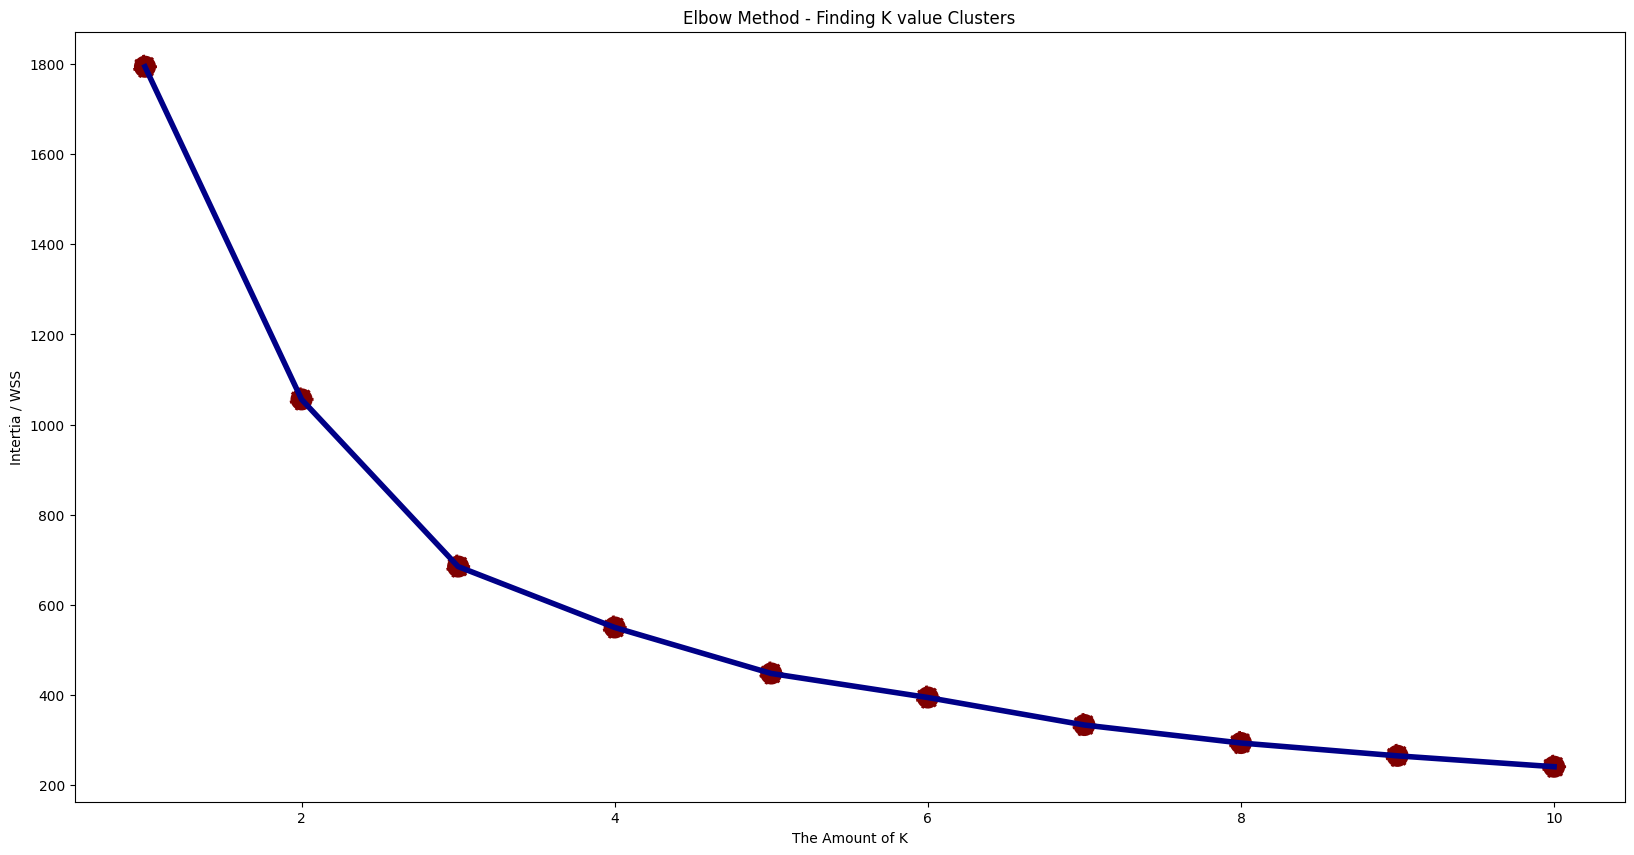

In [17]:
from sklearn.cluster import KMeans
inertia = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(df_scalling.values)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(20, 10))

sns.lineplot(x=range(1, 11), y=inertia, color='#000087', linewidth = 4)
sns.scatterplot(x=range(1, 11), y=inertia, s=300, color='#800000',  linestyle='--')
plt.title('Elbow Method - Finding K value Clusters')
plt.xlabel('The Amount of K')
plt.ylabel('Intertia / WSS')

In [18]:
#Dari hasil diatas elbow nya dipilih pada angka 4,
# karena titik awal sebelum titik selanjutnya memiliki gap yang konstan atau
# titik setelah lekukan tajam sebelum mendatar
from sklearn.cluster import KMeans
kmeans_elbow = KMeans(n_clusters=4, random_state=0)
kmeans_elbow.fit(df_scalling.values)

KMeans(n_clusters=4, random_state=0)

In [19]:
#taruh hasil k-means elbow method ke df dengan nama kolom cluster_elbow
df['cluster_elbow'] = kmeans_elbow.labels_

In [20]:
df

,berat,tinggi,deskripsi,cluster_elbow
0,67.5,168.2,Normal,1
1,119.0,168.7,Obese,2
2,66.5,154.7,Normal,1
3,53.6,166.5,Slim,1
4,66.4,163.5,Normal,1
...,...,...,...,...
892,78.2,159.5,Normal,1
893,75.1,168.1,Normal,2
894,101.5,174.5,Obese,2
895,89.7,156.9,Fat,3


<Axes: xlabel='berat', ylabel='tinggi'>

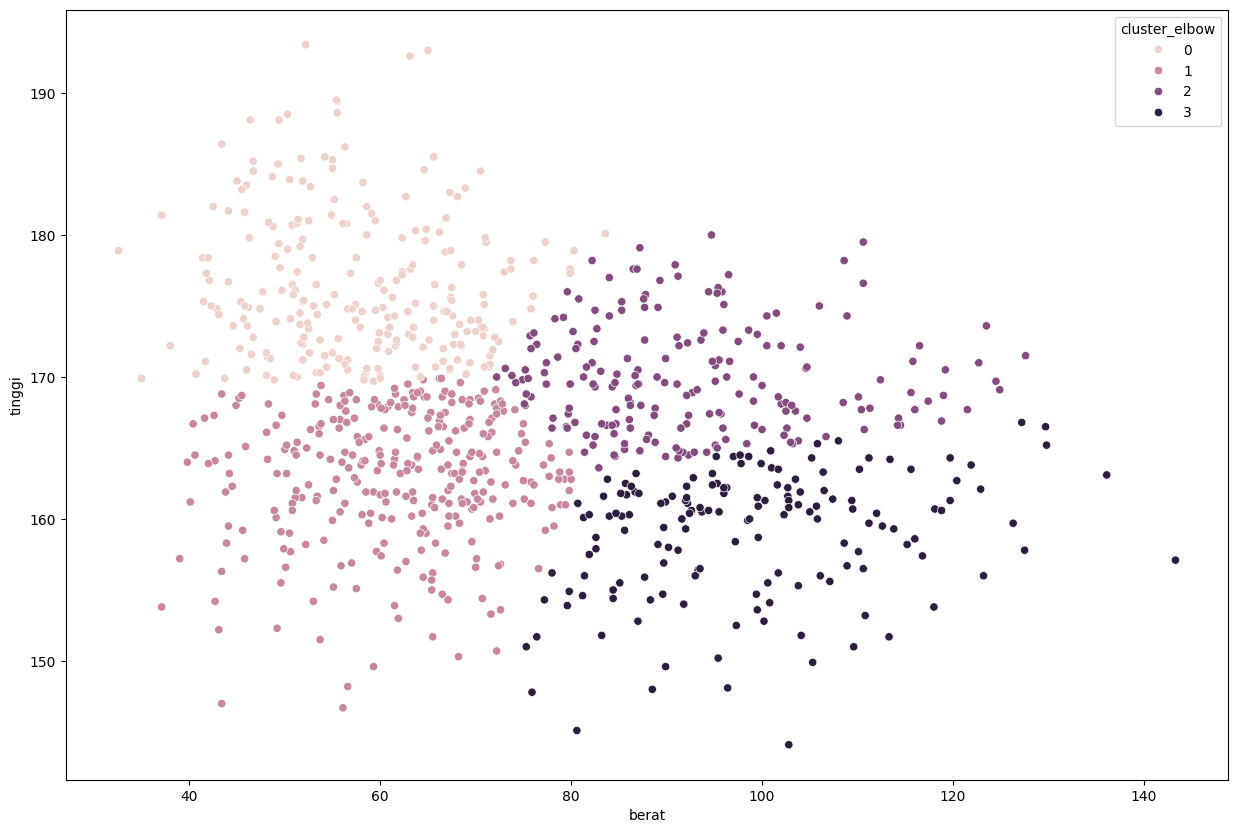

In [21]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='berat', y='tinggi', hue='cluster_elbow')

### Bandingkan hasil dengan label anotator

<Axes: xlabel='berat', ylabel='tinggi'>

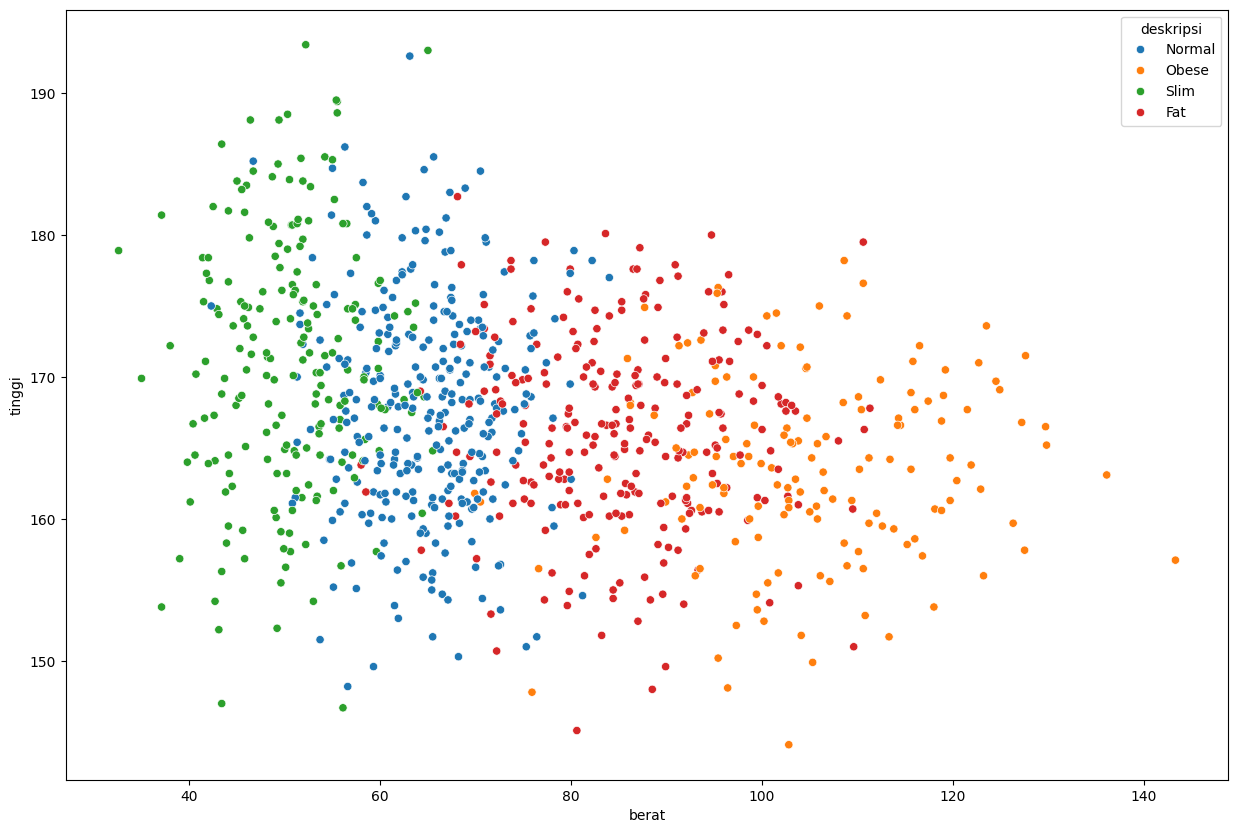

In [22]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='berat', y='tinggi',hue='deskripsi')

### Hasil diatas ketika menggunakan elbow ialah optimal, karena cluster cocok dengan label anotator yang telah tersedia di deskripsi. Dengan kondisi :
1. Cluster 0 -> Normal
2. Cluster 1 -> Fat
3. Cluster 2 -> Slim
4. Cluster 3 -> Obese

### 2. Via Score Plot

In [23]:
!pip install yellowbrick

In [24]:
# Langkah 1: Install setuptools (menyediakan distutils)
!pip install setuptools

In [ ]:
!pip uninstall yellowbrick -y

Found existing installation: yellowbrick 1.5
Uninstalling yellowbrick-1.5:
  Successfully uninstalled yellowbrick-1.5


In [25]:
!pip install yellowbrick

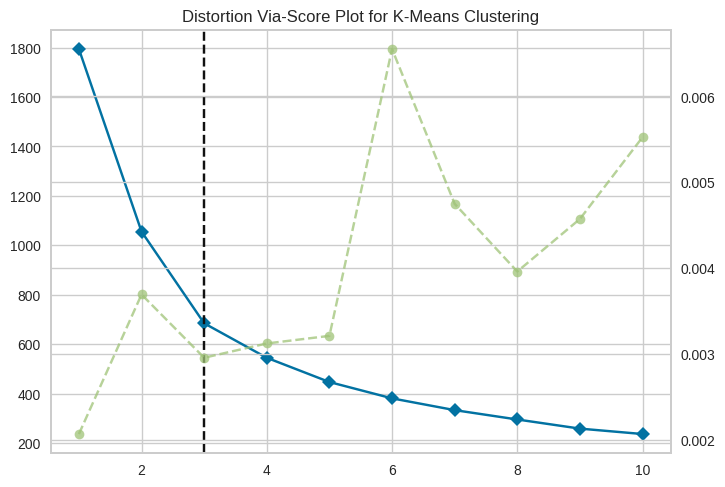

In [26]:
# Via Score Plot
from yellowbrick.cluster import KElbowVisualizer
k_means_via = KMeans()
# k is range of number of clusters.
visualizer = KElbowVisualizer(k_means_via, k=(1,11), timings= True)
visualizer.fit(df_scalling.values)        # Fit the data to the visualizer
plt.title('Distortion Via-Score Plot for K-Means Clustering')
plt.show()

In [36]:
# Dari hasil diatas K-nya dipilih pada angka 3,
# karena titik distorsinya bertemu pada nilai 3 di sumbu x
from sklearn.cluster import KMeans
kmeans_via = KMeans(n_clusters=4, random_state=0)
kmeans_via.fit(df_scalling.values)

KMeans(n_clusters=4, random_state=0)

In [37]:
#taruh hasil k-means via score method ke df dengan nama kolom cluster_via
df['cluster_via'] = kmeans_via.labels_

In [38]:
df

,berat,tinggi,deskripsi,cluster_elbow,cluster_via
0,67.5,168.2,Normal,1,1
1,119.0,168.7,Obese,2,2
2,66.5,154.7,Normal,1,1
3,53.6,166.5,Slim,1,1
4,66.4,163.5,Normal,1,1
...,...,...,...,...,...
892,78.2,159.5,Normal,1,1
893,75.1,168.1,Normal,2,2
894,101.5,174.5,Obese,2,2
895,89.7,156.9,Fat,3,3


## TO DO !
- Lakukan evaluasi pada k-means menggunakan via score secara visualisasi

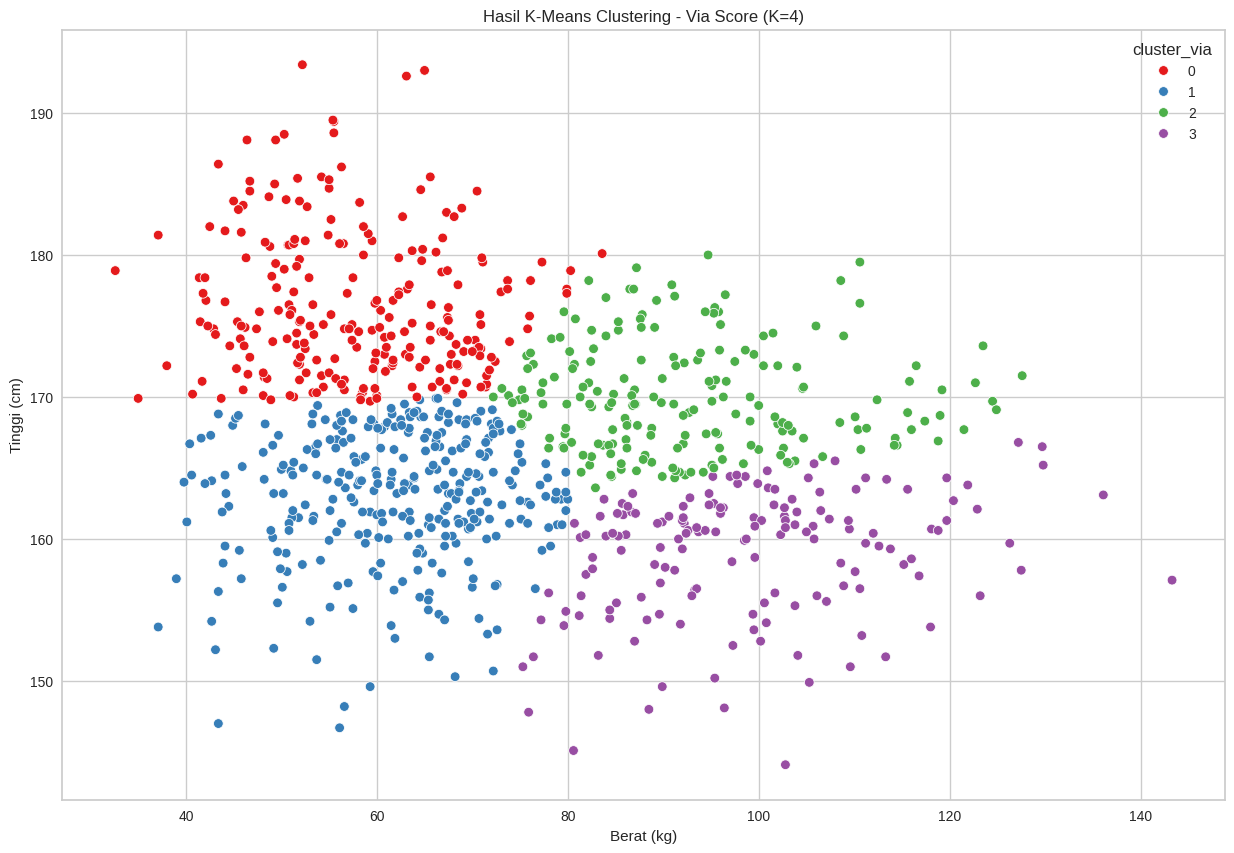

In [39]:
#Lakukan evaluasi setelah dilakukan K-Means
#Bandingkan hasil cluster dengan distribusi data asli
fig, ax = plt.subplots(figsize=(15, 10))
sns.scatterplot(data=df, x='berat', y='tinggi', hue='cluster_via', palette='Set1', ax=ax)
plt.title('Hasil K-Means Clustering - Via Score (K=4)')
plt.xlabel('Berat (kg)')
plt.ylabel('Tinggi (cm)')
plt.show()

### Bandingkan dengan label anotator

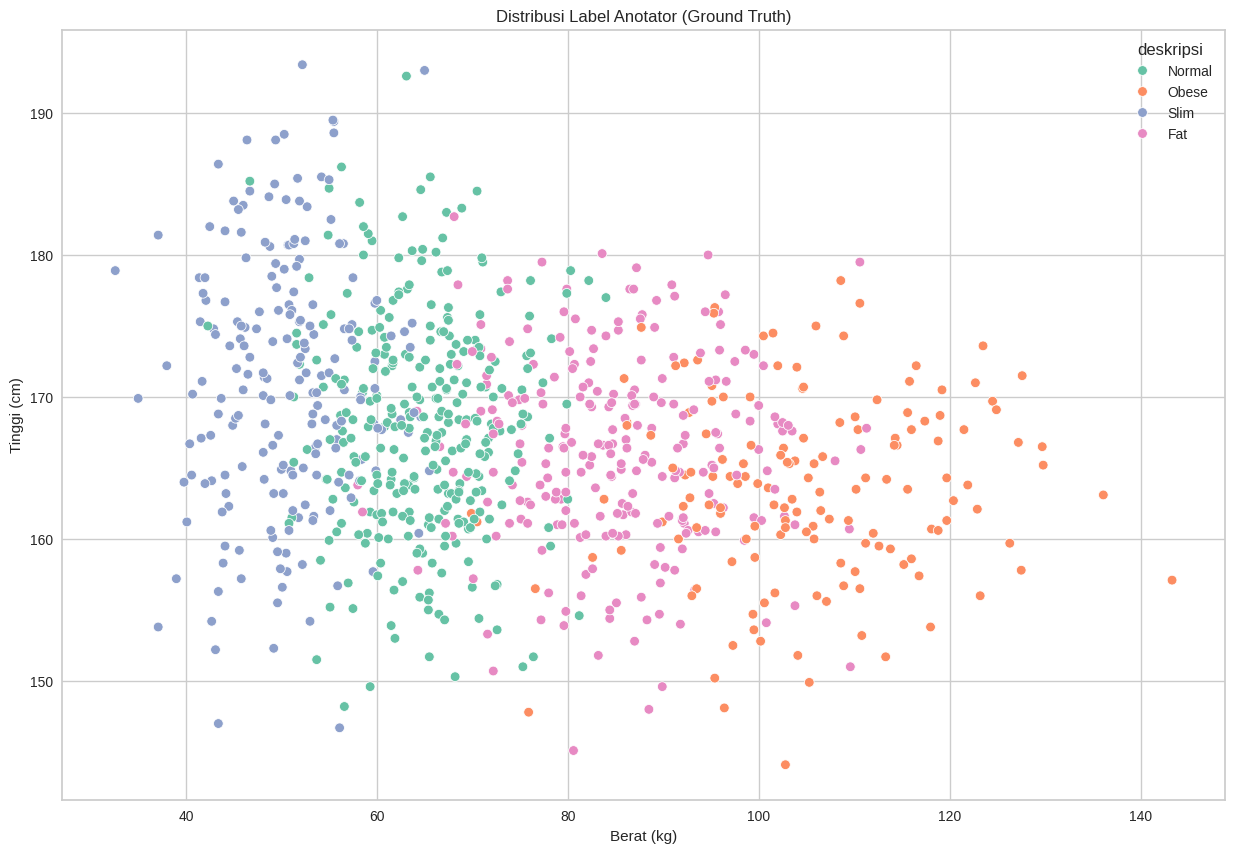

In [40]:
fig, ax = plt.subplots(figsize=(15, 10))
sns.scatterplot(data=df, x='berat', y='tinggi', hue='deskripsi', palette='Set2', ax=ax)
plt.title('Distribusi Label Anotator (Ground Truth)')
plt.xlabel('Berat (kg)')
plt.ylabel('Tinggi (cm)')
plt.show()

### Tulis Interpretasi dari hasil evaluasi diatas :
### Isi disini
### Tulis Interpretasi dari hasil evaluasi diatas :
### Isi disini

1. K-Means berhasil membentuk 4 cluster yang secara umum merepresentasikan kategori berat badan (Slim, Normal, Fat, Obese) berdasarkan fitur berat dan tinggi badan, dengan pola distribusi yang cukup sesuai terhadap label ground truth dari anotator.

2. Cluster dengan performa terbaik adalah Cluster 0 (Slim), karena memiliki batas pemisahan paling tegas dan konsisten dibandingkan cluster lainnya, ditandai dengan minimnya tumpang tindih dengan kelompok label lain pada ground truth.

3. Cluster dengan performa terlemah adalah antara Cluster 2 (Fat) dan Cluster 3 (Obese), karena kedua kategori ini memiliki rentang nilai berat dan tinggi yang saling tumpang tindih sehingga algoritma K-Means kesulitan memisahkan keduanya secara akurat hanya dengan dua fitur tersebut.

4. K-Means memiliki keterbatasan dalam mereplikasi label anotator secara sempurna, karena algoritma ini bekerja murni berdasarkan jarak geometris tanpa mempertimbangkan konteks medis atau standar BMI, sehingga diperlukan fitur tambahan seperti indeks massa tubuh (BMI) atau penambahan nilai K untuk meningkatkan akurasi pengelompokan.





### Thank you :)